In [18]:
import numpy as np
import pandas as pd
from copy import deepcopy

# don't forget to upload utils file to the colab session
import warnings, pylab

warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
pd.options.plotting.backend = "plotly"

df = pd.read_pickle('electronika_clean.pkl')
df

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,1,2970,0,2970,Ника,Товары для дома,Хозтовары,Техника для дома/Техника для ухода за одеждой/...,9,90364
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,1,19490,0,19490,DeLonghi,Мелкая бытовая техника,Приготовление пищи,Техника для кухни/Приготовление пищи/Мультиварки/,9,45673
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,1,19990,0,19990,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/LED телеви...",10,120757
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,1,23680,0,23680,СМК,Мебель,Мягкая мебель,Мебель/Мягкая мебель/Диваны/Трехместные диваны/,11,264580
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,1,2420,0,2420,HP,Аксессуары,Картриджи и бумага,"Компьютеры, ноутбуки, планшеты/Оргтехника/Расх...",9,76102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,1,899,0,899,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17,38755
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,1,1090,0,1090,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17,31908
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,1,6859,0,6859,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17,140459
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,1,9120,0,9120,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17,295956


In [19]:
from ipywidgets import IntProgress
from itertools import product
from catboost import CatBoostRegressor, Pool, metrics, cv
from sklearn.metrics import mean_squared_error


def percentile(n):
    '''Calculate n - percentile of data'''
    def percentile_(x):
        return np.percentile(x, n)
    percentile_.__name__ = 'pctl%s' % n
    return percentile_

# add missing dates to GroupBy.Core object
def fill_missing_dates(x, date_col, freq = None, default_value = np.nan):

    if freq is None:
        try:
           freq = pd.infer_freq(x.set_index(date_col).index[:min(100, x.shape[0])])
        except:
           freq = 'D'

        if freq is None:
          freq = 'D'
          Warning('TS freq is not defined! Daily granularity is provided!')
    # print(freq)
    # new indexes without time breaks
    idx = pd.date_range(x[date_col].min(), x[date_col].max(), freq=freq)
    # print(idx)
    results = x.set_index(date_col).reindex(idx,fill_value = default_value)
    results.index.rename(date_col, inplace = True)

    # groupby_day = x.groupby(pd.PeriodIndex(x[date_col], freq='D'))
    # results = groupby_day.sum(min_count=1)

    # idx = pd.period_range(min_date, max_date)
    # results = results.reindex(idx, fill_value=default_value)

    # results.index.rename(date_col, inplace=True)

    return results.reset_index()


def calc_preag_fill(data, group_col, date_col, target_cols, preagg_method):
    ## calc preaggregation
    data_preag = data.groupby(group_col).agg(
        preagg_method)[target_cols].reset_index()

    ## fill missing dates
    data_preag_filled = data_preag.groupby(group_col[:-1]).apply(
         fill_missing_dates, date_col=date_col).drop(group_col[:-1],
                                                     axis=1).reset_index()

    ## return DataFrame with calculated preaggregation and filled missing dates
    return data_preag # ,  data_preag_filled


def calc_rolling(data_preag_filled, group_col, date_col, method, w):

    ## calc rolling stats
    lf_df_filled = data_preag_filled.groupby(group_col[:-1]).\
        apply(lambda x: x.set_index(date_col).rolling(window=w, min_periods=1).agg(method)).drop(group_col[:-1], axis=1).reset_index(group_col)

    ## return DataFrame with rolled columns from target_vars
    return lf_df_filled

# ewma calculation method
def calc_ewm(data_preag_filled, group_col, date_col, span):
    ## calc ewm stats
    lf_df_filled = data_preag_filled.groupby(group_col[:-1]).\
        apply(lambda x: x.set_index(date_col).ewm(span=span).mean()).drop(group_col[:-1], axis=1).reset_index(group_col)

    ## return DataFrame with rolled columns from target_vars
    return lf_df_filled

# shift ts data
def shift(lf_df_filled, group_col, date_col, lag, kwargs = None):

    lf_df = (lf_df_filled.     # prepare calculations
        set_index(date_col).    # date column as time-index
        groupby(group_col[:-1]).       # ids_col to separate different time series
        apply(lambda x: x.shift(lag, kwargs)).    # aplly shift at lag steps
        drop(group_col[:-1], axis=1).                   # drop ids_col from time df to reset index
        reset_index()              # reset index to return df to no-index state
    )
    # lf_df[date_col] = pd.to_datetime(lf_df[date_col].astype(str))
    # print(lf_df.index)

    ## return DataFrame with following columns: filter_col, id_cols, date_col and shifted stats
    return lf_df


def generate_lagged_features(
        data: pd.DataFrame,
        target_cols: list = ['Demand'],
        id_cols: list = ['SKU_id', 'Store_id'],
        date_col: str = 'Date',
        lags: list = [7, 14, 21, 28],
        windows: list = ['7D', '14D', '28D', '56D'],
        preagg_methods: list = ['mean'],
        agg_methods: list = ['mean', 'median', percentile(10), pd.Series.skew],
        dynamic_filters: list = ['weekday', 'Promo'],
        ewm_params: dict = {'weekday': [14, 28], 'Promo': [14, 42]}) -> pd.DataFrame:

    '''
    data - dataframe with default index
    target_cols - column names for lags calculation
    id_cols - key columns to identify unique values
    date_col - column with datetime format values
    lags - lag values(days)
    windows - windows(days/weeks/months/etc.),
        calculation is performed within time range length of window
    preagg_methods - applied methods before rolling to make
        every value unique for given id_cols
    agg_methods - method of aggregation('mean', 'median', percentile, etc.)
    dynamic_filters - column names to use as filter
    ewm_params - span values(days) for each dynamic_filter
    '''

    data = data.sort_values(date_col)
    out_df = deepcopy(data)
    dates = [min(data[date_col]), max(data[date_col])]

    total = len(target_cols) * len(lags) * len(windows) * len(preagg_methods) * len(agg_methods) * len(dynamic_filters)
    progress = IntProgress(min=0, max=total)
    display(progress)

    for filter_col in dynamic_filters:
        group_col = [filter_col] + id_cols + [date_col]
        for preagg in preagg_methods:
          data_preag_filled = calc_preag_fill(data, group_col, date_col,
                                                  target_cols, preagg)

          ## add ewm features
          for alpha in ewm_params.get(filter_col, []):
              ewm_filled = calc_ewm(data_preag_filled, group_col,
                                    date_col, alpha)
              for lag in lags:
                ewm = shift(ewm_filled, group_col, date_col, lag)

                new_names = {x: "{0}_lag{1}d_alpha{2}_key{3}_preag{4}_{5}_dynamic_ewm".\
                    format(x, lag, alpha, '&'.join(id_cols), preagg, filter_col) for x in target_cols}

                out_df = pd.merge(out_df,
                                  ewm.rename(columns=new_names),
                                  how='left',
                                  on=group_col)

          ## add rolling features
          for w in windows:
              for method in agg_methods:
                  rolling_filled = calc_rolling(data_preag_filled,
                                                group_col, date_col,
                                                method, w)
                  for lag in lags:
                    ## lf_df - DataFrame with following columns: filter_col, id_cols, date_col, shifted rolling stats
                    rolling = shift(rolling_filled, group_col, date_col, lag)

                    method_name = method.__name__ if type(
                        method) != str else method

                    new_names = {x: "{0}_lag{1}d_w{2}_key{3}_preag{4}_ag{5}_{6}_dynamic_rolling".\
                                  format(x, lag, w, '&'.join(id_cols), preagg, method_name, filter_col) for x in target_cols}

                    out_df = pd.merge(out_df,
                                      rolling.rename(columns=new_names),
                                      how='left',
                                      on=group_col)
                    progress.value += 1

    return out_df

Text(0.5, 1.0, 'Goods total')

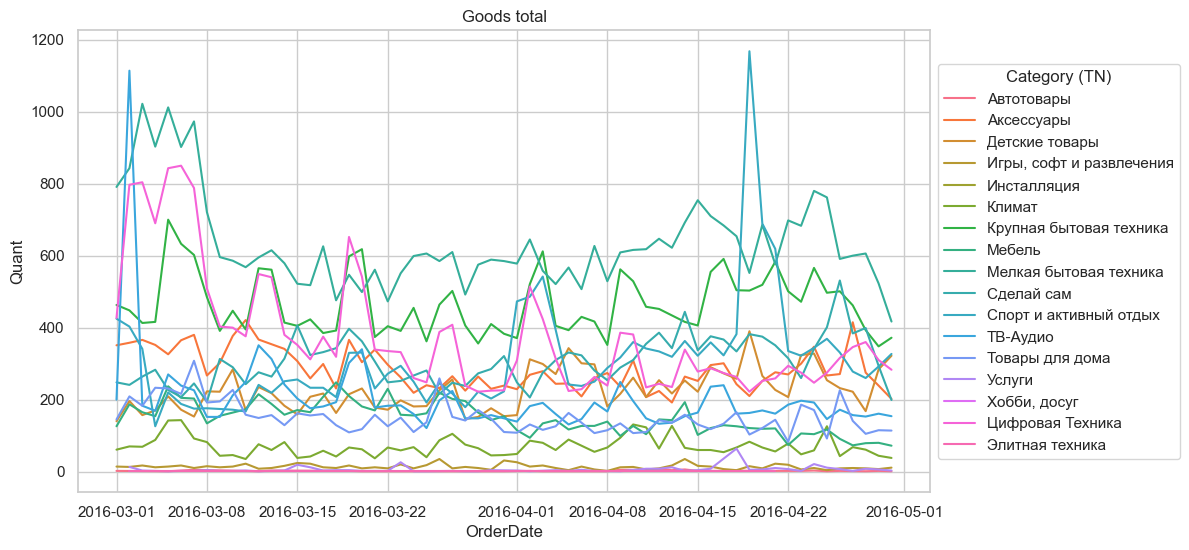

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

placed = df[['TN', 'OrderDate', 'Quant', 'RowSum']].groupby(['TN', 'OrderDate']).sum().reset_index()
placed['OrderDate'] = pd.to_datetime(placed['OrderDate'])

sns.set(style="whitegrid")
plt.figure(figsize=(11, 6))
sns.lineplot(data=placed, x='OrderDate', y='Quant', hue='TN')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Category (TN)")
plt.title('Goods total')


Text(0.5, 1.0, 'Goods sold')

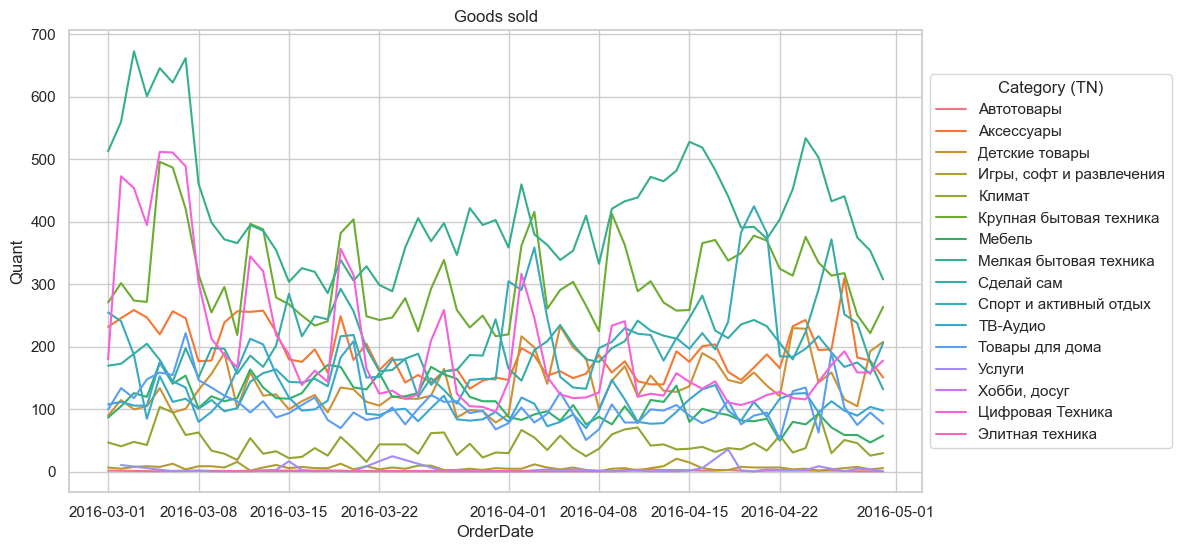

In [21]:
sold = df[df['Status_ID'] == 14][['TN', 'OrderDate', 'Quant']].groupby(['TN', 'OrderDate']).sum().reset_index()
sold['OrderDate'] = pd.to_datetime(sold['OrderDate'])

plt.figure(figsize=(11, 6))
sns.lineplot(data=sold, x='OrderDate', y='Quant', hue='TN')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Category (TN)")
plt.title('Goods sold')


## Крупная бытовая техника

In [22]:
category_name = 'Крупная бытовая техника'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,RowSum,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,9432195,1,1,0
2016-03-02,7986991,2,2,0
2016-03-03,7771378,3,3,0
2016-03-04,7927095,4,4,0
2016-03-05,13094042,5,5,1
2016-03-06,12755973,6,6,1
2016-03-07,10987617,0,7,0
2016-03-08,8983061,1,8,0
2016-03-09,7215502,2,9,0


In [23]:
target_cols = ['RowSum']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,RowSum,weekday,monthday,is_weekend,NoFilter,RowSum_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,RowSum_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,9432195,1,1,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,7986991,2,2,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,7771378,3,3,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,7927095,4,4,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,13094042,5,5,1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,9434044,1,26,0,1,8.693595e+06,8.360149e+06,8.631224e+06,8.471044e+06,...,6959499.8,6959499.8,10626934.5,9871449.1,8462853.45,8458302.70,6944434.8,6927613.1,10608439.5,11504582.6
57,2016-04-27,8655956,2,27,0,1,8.617967e+06,8.300233e+06,8.594915e+06,8.429811e+06,...,6959499.8,6959499.8,10626934.5,9871449.1,8437346.20,8458035.85,6944434.8,6927613.1,10608439.5,11504582.6
58,2016-04-28,7453044,3,28,0,1,8.472280e+06,8.109387e+06,8.518191e+06,8.315490e+06,...,7141643.2,6897669.6,10626934.5,9871449.1,8462331.95,8224084.50,6944434.8,6857465.3,10608439.5,10214390.1
59,2016-04-29,6613249,4,29,0,1,8.279975e+06,8.447398e+06,8.411716e+06,8.485278e+06,...,6993121.9,6897669.6,10626934.5,10466818.5,8356483.20,8139073.70,6944434.8,6857465.3,10608439.5,10128091.5


In [24]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
y = train_df.RowSum

print(X.dtypes)

categorical_features_indices = np.where(X.dtypes != float)[0]

weekday                                                                int32
monthday                                                               int32
is_weekend                                                             int64
NoFilter                                                               int64
RowSum_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag14d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
RowSum_lag20d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
RowSum_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
RowSum_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
RowSum_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling    float64

In [26]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum
predictions = model.predict(X_test)

daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,
2016-03-01,9432195,1,1,0,1,-1.000000e+00
2016-03-02,7986991,2,2,0,1,-1.000000e+00
2016-03-03,7771378,3,3,0,1,-1.000000e+00
2016-03-04,7927095,4,4,0,1,-1.000000e+00
2016-03-05,13094042,5,5,1,1,-1.000000e+00
...,...,...,...,...,...,...
2016-04-26,9434044,1,26,0,1,8.066083e+06
2016-04-27,8655956,2,27,0,1,8.080145e+06
2016-04-28,7453044,3,28,0,1,7.967462e+06


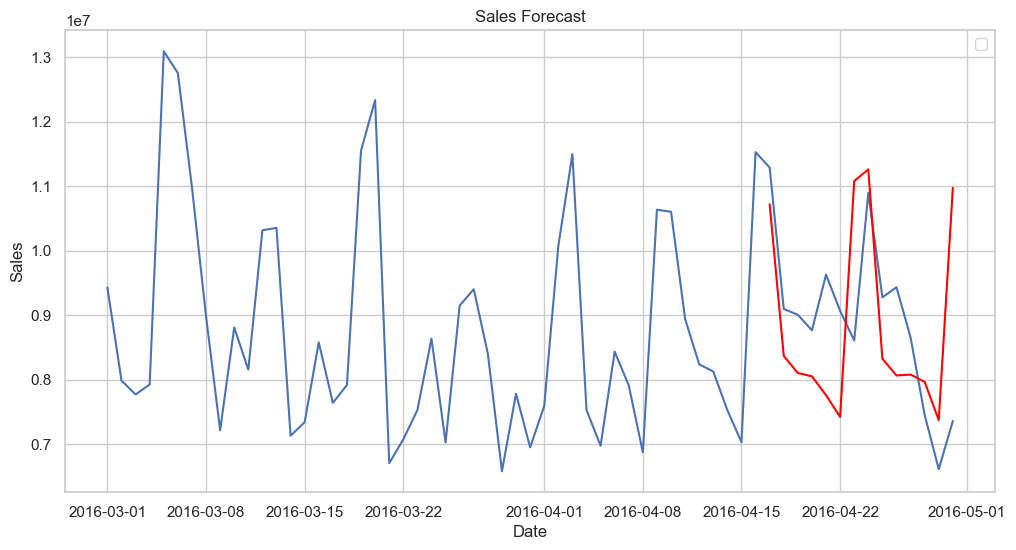

MAE: 1217907.180251013
MSE: 2260653916549.1553
MAPE: 14.267912589969061


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.RowSum)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['RowSum'][-14:], predictions)
mse = mean_squared_error(daily_sales['RowSum'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['RowSum'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Мелкая бытовая техника

In [29]:
category_name = 'Мелкая бытовая техника'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,RowSum,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,3224024,1,1,0
2016-03-02,3665191,2,2,0
2016-03-03,4247324,3,3,0
2016-03-04,4376917,4,4,0
2016-03-05,4963810,5,5,1
2016-03-06,4569939,6,6,1
2016-03-07,4509576,0,7,0
2016-03-08,2844088,1,8,0
2016-03-09,2864152,2,9,0


In [30]:
target_cols = ['RowSum']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,RowSum,weekday,monthday,is_weekend,NoFilter,RowSum_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,RowSum_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,3224024,1,1,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,3665191,2,2,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,4247324,3,3,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,4376917,4,4,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,4963810,5,5,1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,2584894,1,26,0,1,3.137093e+06,3.211113e+06,3.171191e+06,3.221717e+06,...,2792950.0,2918071.1,3734399.1,3791558.1,3264709.15,3176742.20,2870698.0,2737067.7,3774870.3,3774870.3
57,2016-04-27,2854585,2,27,0,1,3.101063e+06,3.228148e+06,3.149294e+06,3.230328e+06,...,2788063.6,2918071.1,3519345.9,3791558.1,3239579.15,3214458.50,2856038.8,2870698.0,3774870.3,3774870.3
58,2016-04-28,3070329,3,28,0,1,3.127985e+06,3.145935e+06,3.160313e+06,3.185023e+06,...,2788063.6,2792950.0,3508587.0,3791558.1,3243246.80,3200760.75,2856038.8,2740055.9,3774870.3,3774870.3
59,2016-04-29,2844599,4,29,0,1,3.200298e+06,3.153033e+06,3.196798e+06,3.186045e+06,...,2788063.6,2792950.0,3643175.8,3791558.1,3250916.10,3214565.05,2856038.8,2740055.9,3774870.3,3774870.3


In [31]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
y = train_df.RowSum

print(X.dtypes)

categorical_features_indices = np.where(X.dtypes != float)[0]

weekday                                                                int32
monthday                                                               int32
is_weekend                                                             int64
NoFilter                                                               int64
RowSum_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag14d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
RowSum_lag20d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
RowSum_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
RowSum_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
RowSum_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling    float64

In [32]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum
predictions = model.predict(X_test)

daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,
2016-03-01,3224024,1,1,0,1,-1.000000e+00
2016-03-02,3665191,2,2,0,1,-1.000000e+00
2016-03-03,4247324,3,3,0,1,-1.000000e+00
2016-03-04,4376917,4,4,0,1,-1.000000e+00
2016-03-05,4963810,5,5,1,1,-1.000000e+00
...,...,...,...,...,...,...
2016-04-26,2584894,1,26,0,1,3.123284e+06
2016-04-27,2854585,2,27,0,1,3.105819e+06
2016-04-28,3070329,3,28,0,1,3.186003e+06


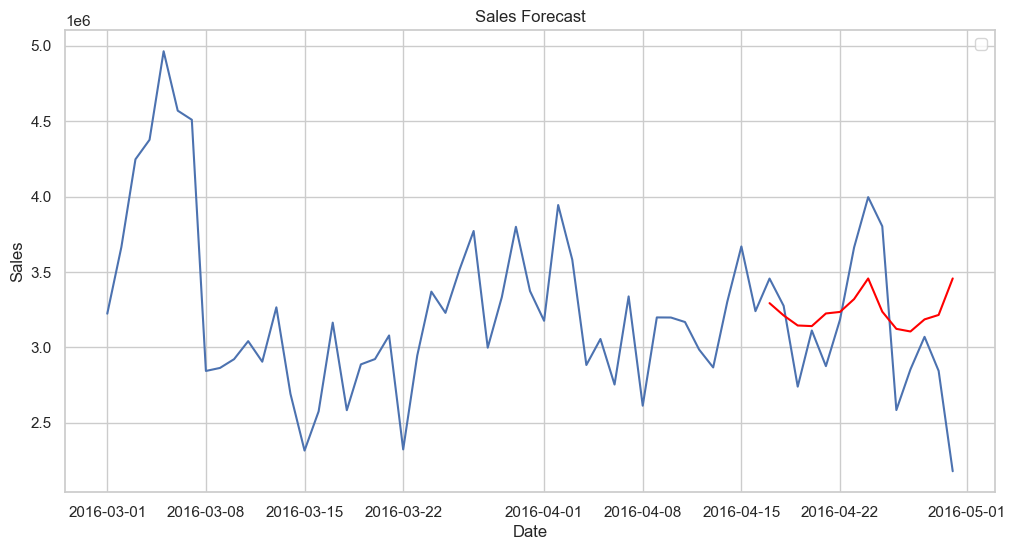

MAE: 361712.1935246217
MSE: 227631881956.7271
MAPE: 12.783310058237943


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.RowSum)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['RowSum'][-14:], predictions)
mse = mean_squared_error(daily_sales['RowSum'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['RowSum'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# Сделай Сам

In [34]:
category_name = 'Сделай сам'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,RowSum,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,1635392,1,1,0
2016-03-02,1436973,2,2,0
2016-03-03,1872283,3,3,0
2016-03-04,1485503,4,4,0
2016-03-05,1211762,5,5,1
2016-03-06,1231367,6,6,1
2016-03-07,1328828,0,7,0
2016-03-08,1004958,1,8,0
2016-03-09,1595321,2,9,0


In [35]:
target_cols = ['RowSum']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,RowSum,weekday,monthday,is_weekend,NoFilter,RowSum_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,RowSum_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,RowSum_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,RowSum_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,RowSum_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,1635392,1,1,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,1436973,2,2,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,1872283,3,3,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,1485503,4,4,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,1211762,5,5,1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,3374833,1,26,0,1,1.843982e+06,1.639554e+06,1.748595e+06,1.629275e+06,...,1316085.6,1291966.5,2256114.7,1713272.6,1668752.45,1607885.60,1335481.5,1335481.5,2236812.1,1796551.8
57,2016-04-27,2863092,2,27,0,1,1.905024e+06,1.650435e+06,1.788404e+06,1.636034e+06,...,1316085.6,1316085.6,2290400.4,1720227.9,1716663.65,1611063.20,1407838.8,1335481.5,2269285.2,1796551.8
58,2016-04-28,2789969,3,28,0,1,1.951439e+06,1.643314e+06,1.821755e+06,1.633183e+06,...,1316085.6,1316085.6,2290400.4,1720227.9,1749263.85,1581042.05,1407838.8,1335481.5,2269285.2,1732939.2
59,2016-04-29,1695108,4,29,0,1,1.937662e+06,1.632817e+06,1.823653e+06,1.628182e+06,...,1465643.7,1316085.6,2290400.4,1720227.9,1767262.15,1571684.80,1407838.8,1335481.5,2269285.2,1721807.7


In [36]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
y = train_df.RowSum

print(X.dtypes)

categorical_features_indices = np.where(X.dtypes != float)[0]

weekday                                                                int32
monthday                                                               int32
is_weekend                                                             int64
NoFilter                                                               int64
RowSum_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
RowSum_lag14d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
RowSum_lag20d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
RowSum_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
RowSum_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
RowSum_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling    float64

In [37]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum
predictions = model.predict(X_test)

daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,
2016-03-01,1635392,1,1,0,1,-1.000000e+00
2016-03-02,1436973,2,2,0,1,-1.000000e+00
2016-03-03,1872283,3,3,0,1,-1.000000e+00
2016-03-04,1485503,4,4,0,1,-1.000000e+00
2016-03-05,1211762,5,5,1,1,-1.000000e+00
...,...,...,...,...,...,...
2016-04-26,3374833,1,26,0,1,1.798691e+06
2016-04-27,2863092,2,27,0,1,1.843860e+06
2016-04-28,2789969,3,28,0,1,1.904354e+06


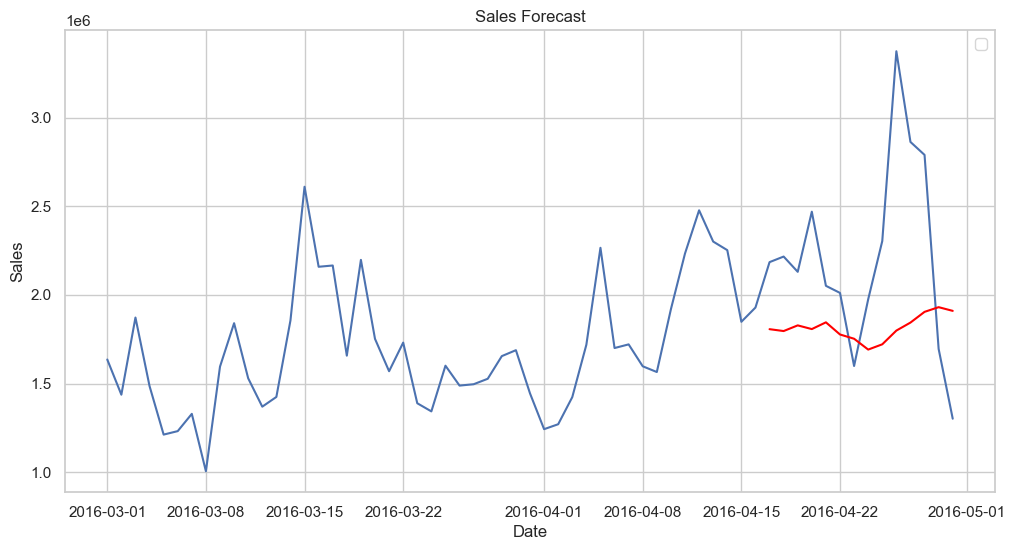

MAE: 539210.3855014623
MSE: 437429220246.19366
MAPE: 23.068382239534426


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.RowSum)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['RowSum'][-14:], predictions)
mse = mean_squared_error(daily_sales['RowSum'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['RowSum'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')